In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Minibatches

that section and that section are the two ends of a spectrum.
Gradient descent pays a full pass over the dataset for one exact update;
stochastic gradient descent pays for a single example and takes a noisy step.
Every model we have trained in this book actually did something in between:
it averaged the gradient over a *minibatch* of a few dozen to a few hundred
examples. The statistical half of the justification appeared in
that section, where we measured that averaging $b$ independent gradients
cuts the variance by a factor of $b$. This section supplies the computational
half: on modern processors, $b$ examples at once cost far less than $b$
examples one at a time, for reasons of caches, vector units, and dispatch
overhead rather than statistics. Along the way we build the equipment the
rest of the chapter trains with — a timer, a small real regression dataset,
and a harness that accepts any optimizer written as an update rule — and we
finish by racing gradient descent, SGD, and minibatch SGD against the wall
clock.

## Vectorization and Caches

The bluntest reason to batch is parallel hardware. Training on multiple GPUs
and multiple servers requires sending at least one example to each device,
so with 8 GPUs per server and 16 servers the minibatch is already no smaller
than 128 if every device is to contribute.

On a single GPU or CPU the reason is subtler: arithmetic is abundant and
memory traffic is not. A current server CPU sustains on the order of
$10^{12}$ to $10^{13}$ floating point operations per second across its cores
and vector units, yet its memory interface delivers a few hundred gigabytes
per second. A GPU is more lopsided still: on the order of $10^{14}$
operations per second in single precision — and another order of magnitude
through its matrix units at the reduced precisions used for deep learning —
against a few terabytes per second of memory bandwidth. In both cases
arithmetic outruns bandwidth by roughly two orders of magnitude, so keeping
the processor busy requires each byte fetched from memory to take part in
tens to hundreds of operations before being evicted.

Processors bridge the gap with a hierarchy of memories: a small number of
registers, then L1, L2, and often L3 caches of increasing size and latency
and decreasing bandwidth, the largest shared among cores. Access patterns
matter as much as volume: the first access to a region of memory is
expensive, while the sequential reads that follow (a *burst read*) are
comparatively cheap. See this
[Wikipedia article](https://en.wikipedia.org/wiki/Cache_hierarchy) for a more
in-depth discussion. Whether the hierarchy helps is a property of the
algorithm, not the hardware: data must be *reused* while it is still
resident. Consider matrix multiplication, $\mathbf{A} = \mathbf{B}\mathbf{C}$.
We have several options for computing $\mathbf{A}$:

1. We could compute $\mathbf{A}_{ij} = \mathbf{B}_{i,:} \mathbf{C}_{:,j}$, i.e., elementwise by means of dot products.
1. We could compute $\mathbf{A}_{:,j} = \mathbf{B} \mathbf{C}_{:,j}$, i.e., one column at a time. Likewise we could compute $\mathbf{A}$ one row $\mathbf{A}_{i,:}$ at a time.
1. We could simply compute $\mathbf{A} = \mathbf{B} \mathbf{C}$ in one go.
1. We could break $\mathbf{B}$ and $\mathbf{C}$ into smaller block matrices and compute $\mathbf{A}$ one block at a time.

Option 1 fetches a row and a column for every single output element, and
since matrices are laid out linearly in memory, one of the two is read from
widely scattered addresses. Option 2 keeps the column vector
$\mathbf{C}_{:,j}$ in cache while traversing $\mathbf{B}$, halving the memory
traffic. Option 3 is best, but most matrices do not fit into cache — that is
the problem we started with. Option 4 is the practical answer: move blocks of
both matrices into cache and multiply them there, so every loaded byte is
reused across a whole block of outputs. Optimized libraries do this for us.

Memory is not the only overhead. Every operation launched from Python pays
for the interpreter, the framework's bookkeeping, and, on a GPU, a kernel
launch — microseconds per operation, against the nanoseconds of arithmetic a
small operation actually contains. The remedy is the same as for memory:
fewer, larger operations. Let's measure how much all of this matters in
practice.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import numpy as np
import time
import torch
from torch import nn

A = torch.zeros(256, 256)
B = torch.randn(256, 256)
C = torch.randn(256, 256)

Since we will benchmark the running time frequently in the rest of the book, let's define a timer.

In [2]:
class Timer:
    """Record multiple running times."""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """Start the timer."""
        self.tik = time.time()

    def stop(self):
        """Stop the timer and record the time in a list."""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """Return the average time."""
        return sum(self.times) / len(self.times)

    def sum(self):
        """Return the sum of time."""
        return sum(self.times)

    def cumsum(self):
        """Return the accumulated time."""
        return np.array(self.times).cumsum().tolist()

timer = Timer()

Elementwise assignment (option 1) iterates over all rows and columns of
$\mathbf{B}$ and $\mathbf{C}$ respectively to assign the result to
$\mathbf{A}$ one dot product at a time.

In [3]:
# Compute A = BC one element at a time
timer.start()
for i in range(256):
    for j in range(256):
        A[i, j] = torch.dot(B[i, :], C[:, j])
timer.stop()

0.8051884174346924

A faster strategy is column-wise assignment (option 2).

In [4]:
# Compute A = BC one column at a time
timer.start()
for j in range(256):
    A[:, j] = torch.mv(B, C[:, j])
timer.stop()

0.013139963150024414

Last, we perform the entire operation in one call (option 3). Multiplying two
matrices $\mathbf{B} \in \mathbb{R}^{m \times n}$ and
$\mathbf{C} \in \mathbb{R}^{n \times p}$ takes approximately $2mnp$ floating
point operations, when scalar multiplication and addition are counted
separately (fused in practice). Multiplying two $256 \times 256$ matrices
thus takes $0.03$ billion floating point operations. Let's see the respective
speeds.

In [5]:
# Compute A = BC in one go
timer.start()
A = torch.mm(B, C)
timer.stop()

gigaflops = [0.03 / i for i in timer.times]
print(f'performance in Gigaflops: element {gigaflops[0]:.3f}, '
      f'column {gigaflops[1]:.3f}, full {gigaflops[2]:.3f}')

performance in Gigaflops: element 0.037, column 2.283, full 20.689


On the CPU the three strategies land orders of magnitude apart: the
elementwise loop runs in the megaflop range, the single library call in the
gigaflops. Nothing about the arithmetic changed between them — only how much
of it we exposed to the library per call, and hence how much overhead and
memory traffic each floating point operation had to carry.

## Minibatch Gradients

The same economics applies when the operands are training examples rather
than matrix columns. Processing one observation at a time means many
matrix–vector (or even vector–vector) products, each carrying the full
dispatch overhead — during inference just as during training. That is the
computational case against the single-example update
$\mathbf{w} \leftarrow \mathbf{w} - \eta_t \mathbf{g}_t$ with

$$\mathbf{g}_t = \partial_{\mathbf{w}} f(\mathbf{x}_{t}, \mathbf{w}).$$

Its minibatch counterpart averages over a set $\mathcal{B}_t$ of
$b \stackrel{\textrm{def}}{=} |\mathcal{B}_t|$ examples drawn uniformly at
random from the training set:

$$\mathbf{g}_t = \partial_{\mathbf{w}} \frac{1}{b} \sum_{i \in \mathcal{B}_t} f(\mathbf{x}_{i}, \mathbf{w}).$$

Statistically this changes exactly two things. The expectation is untouched:
the minibatch gradient is as unbiased as the single-example one. The variance
drops by a factor of $b$, since we average $b$ independent draws;
equivalently, the noise amplitude shrinks by $b^{-1/2}$. This is the $1/b$
law we measured on a real network in that section.

Batching therefore helps twice, and the two reasons deserve to be kept apart.
The *hardware* reason is this section's: $b$ examples share one pass over the
weights and one round of dispatch overhead, so the cost per example falls
steeply as $b$ grows from 1 and flattens once the device is saturated. The
*statistical* reason is that section's: a quieter gradient. But
amplitude only falls as $b^{-1/2}$, so spending $100\times$ more compute per
step buys a $10\times$ quieter direction. Both effects saturate, and neither
tells us when a bigger batch stops converting into faster training. That
question, how large is too large, depends on the optimization dynamics
themselves; it has a name, the *critical batch size*, and gets its own
treatment in that section. In practice one picks $b$ large
enough to keep the device busy and small enough to fit its memory. When the
batch you want exceeds memory, gradients can be *accumulated* over several
forward–backward passes before a single update — arithmetically identical to
a larger batch — a systems technique we return to in
that section.

To see the hardware side in isolation, we perform the same matrix
multiplication as before, but broken into "minibatches" of 64 columns at a
time.

In [6]:
timer.start()
for j in range(0, 256, 64):
    A[:, j:j+64] = torch.mm(B, C[:, j:j+64])
timer.stop()
print(f'performance in Gigaflops: block {0.03 / timer.times[3]:.3f}')

performance in Gigaflops: block 17.145


Computation on the minibatch is essentially as efficient as on the full
matrix: 64 columns at a time is already enough work per dispatch to amortize
the overhead. One caveat before transferring this intuition wholesale to
training: layers that compute statistics *across* the batch — batch
normalization (that section) being the prominent case — change
behavior as $b$ grows, since the noise they inject shrinks with the batch;
see @Ioffe.2017 for how to rescale the relevant terms.

## Reading the Dataset

The experiments in the rest of this chapter run on a small real regression
task: predicting aircraft wing
[self-noise](https://archive.ics.uci.edu/dataset/291/airfoil+self+noise)
from five physical features, a dataset collected by NASA. We use the first
$1{,}500$ examples and whiten the data, removing the mean and rescaling the
variance to $1$ per coordinate. It is deliberately modest: each training run
takes seconds, so we can afford to rerun it under every optimizer the chapter
introduces.

In [7]:

d2l.DATA_HUB['airfoil'] = (d2l.DATA_URL + 'airfoil_self_noise.dat',
                           '76e5be1548fd8222e5074cf0faae75edff8cf93f')


def get_data_ch11(batch_size=10, n=1500):
    data = np.genfromtxt(d2l.download('airfoil'),
                         dtype=np.float32, delimiter='\t')
    data = torch.from_numpy((data - data.mean(axis=0)) / data.std(axis=0))
    data_iter = d2l.load_array((data[:n, :-1], data[:n, -1]),
                               batch_size, is_train=True)
    return data_iter, data.shape[1]-1

## Implementation from Scratch

Recall the minibatch update derived in that section and
implemented from scratch in that section.
Here we make it slightly more general, giving it the call signature that
every optimizer in this chapter will share: a `states` input holding whatever
auxiliary variables the algorithm carries (SGD carries none; momentum and
Adam will), and a `hyperparams` dictionary. The training function averages
the loss over each minibatch, so the update rule never needs to divide by the
batch size.

In [8]:
def sgd(params, states, hyperparams):
    for p in params:
        with torch.no_grad():
            p.sub_(hyperparams['lr'] * p.grad)
        p.grad.zero_()

Next, a generic training function. It initializes a linear regression model
and trains it with any update rule of the above signature, plotting the loss
against elapsed wall-clock time — the axis that actually matters when
comparing optimizers.

In [9]:

def train_ch11(trainer_fn, states, hyperparams, data_iter,
               feature_dim, num_epochs=2):
    # Initialization
    w = torch.normal(mean=0.0, std=0.01, size=(feature_dim, 1),
                     requires_grad=True)
    b = torch.zeros((1), requires_grad=True)
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    # Train
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[0, num_epochs], ylim=[0.22, 0.35])
    n, timer = 0, d2l.Timer()
    for _ in range(num_epochs):
        for X, y in data_iter:
            l = loss(net(X), y).mean()
            l.backward()
            trainer_fn([w, b], states, hyperparams)
            n += X.shape[0]
            if n % 200 == 0:
                timer.stop()
                animator.add(n/X.shape[0]/len(data_iter),
                             (d2l.evaluate_loss(net, data_iter, loss),))
                timer.start()
    print(f'loss: {animator.Y[0][-1]:.3f}, {timer.sum()/num_epochs:.3f} sec/epoch')
    return timer.cumsum(), animator.Y[0]

Now we can race the extremes against the middle. First, batch gradient
descent: setting the minibatch size to 1500, the full dataset, updates the
parameters once per epoch. Progress stalls after roughly six steps — each
step is well aimed, but there are too few of them.

loss: 0.244, 0.029 sec/epoch


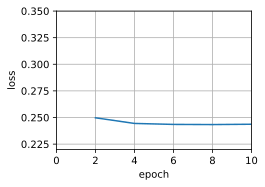

In [10]:
def train_sgd(lr, batch_size, num_epochs=2):
    data_iter, feature_dim = get_data_ch11(batch_size)
    return train_ch11(
        sgd, None, {'lr': lr}, data_iter, feature_dim, num_epochs)

gd_res = train_sgd(1, 1500, 10)

At the opposite extreme, batch size 1 is stochastic gradient descent: 1500
updates per epoch, at a constant (and necessarily small) learning rate. The
loss falls quickly at first and then the decline slows. Both procedures
process 1500 examples per epoch, but SGD takes *more clock time per epoch*
than gradient descent here: it dispatches 1500 tiny operations where gradient
descent dispatches one large one — the overhead story of the previous
section, paid at every step.

loss: 0.245, 0.399 sec/epoch


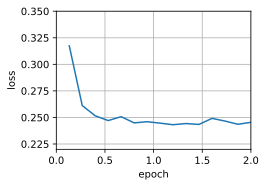

In [11]:
sgd_res = train_sgd(0.005, 1)

With a batch size of 100 the time per epoch drops below both extremes.

loss: 0.244, 0.018 sec/epoch


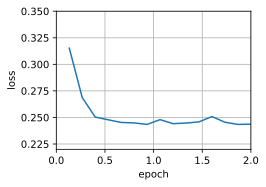

In [12]:
mini1_res = train_sgd(.4, 100)

Reducing the batch size to 10 raises the time per epoch again: the work per
dispatch is getting too small to run efficiently.

loss: 0.246, 0.056 sec/epoch


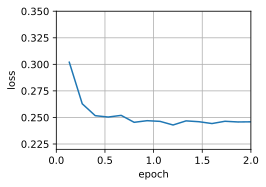

In [13]:
mini2_res = train_sgd(.05, 10)

Plotting loss against wall-clock time for all four experiments makes the
trade explicit. SGD converges fastest *per example processed*, yet reaches a
given loss *slower than gradient descent by the clock*, because it computes
gradients one example at a time. Minibatch SGD takes both savings at once:
batch size 10 beats pure SGD, and batch size 100 beats even gradient descent
on runtime.

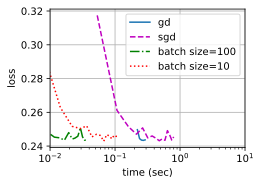

In [14]:
d2l.set_figsize([6, 3])
d2l.plot(*list(map(list, zip(gd_res, sgd_res, mini1_res, mini2_res))),
         'time (sec)', 'loss', xlim=[1e-2, 10], xscale='log',
         legend=['gd', 'sgd', 'batch size=100', 'batch size=10'])

## Concise Implementation

Every framework ships these loops behind an optimizer object. Using it makes
the training function shorter and less error-prone; we wrap the pattern into
a generic function used throughout this chapter.

In [15]:

def train_concise_ch11(trainer_fn, hyperparams, data_iter, num_epochs=4):
    # Initialization
    net = nn.Sequential(nn.Linear(5, 1))
    def init_weights(module):
        if type(module) == nn.Linear:
            torch.nn.init.normal_(module.weight, std=0.01)
    net.apply(init_weights)

    optimizer = trainer_fn(net.parameters(), **hyperparams)
    loss = nn.MSELoss(reduction='none')
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[0, num_epochs], ylim=[0.22, 0.35])
    n, timer = 0, d2l.Timer()
    for _ in range(num_epochs):
        for X, y in data_iter:
            optimizer.zero_grad()
            out = net(X)
            y = y.reshape(out.shape)
            l = loss(out, y)
            l.mean().backward()
            optimizer.step()
            n += X.shape[0]
            if n % 200 == 0:
                timer.stop()
                # `MSELoss` computes squared error without the 1/2 factor
                animator.add(n/X.shape[0]/len(data_iter),
                             (d2l.evaluate_loss(net, data_iter, loss) / 2,))
                timer.start()
    print(f'loss: {animator.Y[0][-1]:.3f}, {timer.sum()/num_epochs:.3f} sec/epoch')

Repeating the batch-size-10 experiment through the framework optimizer shows
the same behavior.

loss: 0.242, 0.059 sec/epoch


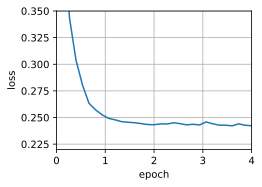

In [16]:
data_iter, _ = get_data_ch11(10)
trainer = torch.optim.SGD
train_concise_ch11(trainer, {'lr': 0.01}, data_iter)

## Summary

Minibatches are cheap for mechanical reasons: a batched operation shares one
round of dispatch overhead and one pass over the weights across $b$ examples,
and blocked computation keeps data in cache, where the same processor runs
orders of magnitude faster than when it waits on main memory. Combined with
the $1/b$ variance reduction measured in that section, this is why
minibatch SGD dominates both of its parents on the wall clock, as the race in
this section showed. Choosing $b$ to fill the device without exhausting its
memory captures most of the benefit; how far the statistics allow batch size
to grow before the returns vanish — the critical batch size — is the subject
of that section.

## Exercises

1. Modify the batch size and learning rate and observe the rate of decline for the value of the objective function and the time consumed in each epoch.
1. In the blocked matrix multiplication benchmark, vary the block width over $\{1, 4, 16, 64, 256\}$ and time each variant. Where does throughput saturate, and why does it saturate well before the full width of 256? Then repeat the element/column/full comparison with $4096 \times 4096$ matrices on a GPU and explain what changes.
1. Compare minibatch stochastic gradient descent with a variant that actually *samples with replacement* from the training set. What happens?
1. An evil genie replicates your dataset without telling you (i.e., each observation occurs twice and your dataset grows to twice its original size, but nobody told you). How does the behavior of stochastic gradient descent, minibatch stochastic gradient descent and that of gradient descent change?
1. Implement gradient accumulation on top of `train_ch11`: sum gradients over $k$ consecutive batches of size $b$ and update once with their average. Verify that the loss trajectory matches a run with batch size $kb$ when plotted against examples processed, then compare the two against wall-clock time.

[Discussions](https://d2l.discourse.group/t/1068)